In [1]:
"""
main.py
=======
Orchestrator for the RSS Strandeiland reliability analysis.

Workflow
--------
1.  Deterministic unity checks  (quick sanity check before probabilistic run)
2.  FORM analysis for each stochastic failure mechanism
3.  Monte Carlo simulation as cross-check for selected mechanisms
4.  Compare results to target failure probabilities
5.  Derive partial safety factors in table 
"""

'\nmain.py\n=======\nOrchestrator for the RSS Strandeiland reliability analysis.\n\nWorkflow\n--------\n1.  Deterministic unity checks  (quick sanity check before probabilistic run)\n2.  FORM analysis for each stochastic failure mechanism\n3.  Monte Carlo simulation as cross-check for selected mechanisms\n4.  Compare results to target failure probabilities\n5.  Derive partial safety factors in table \n'

# Reliability analysis

In [2]:
import numpy as np
import os
import openturns as ot
ot.Log.Show(ot.Log.NONE)

import Parameters as P
import Probabilistic  # module handle: globals below are set inside input_OpenTurns
from Probabilistic import (input_OpenTurns, run_FORM_analysis,
                           run_MonteCarloSimulation, importance_factors,
                           failure_domain_reachable)
#LSF imports
from Lsf_overtopping import (
    build_openturns_hydraulic_distribution,
    check_overtopping,
    check_overflow,
    fit_hydra_margins,
    make_lsf_overtopping_joint,
    make_lsf_overflow_joint,
    project_structure_config,
    estimate_gaussian_copula_rho_from_cooccurrence,
)
from Lsf_erosion     import unity_checks_erosion, lsf_toe_stone, lsf_toe_width
from Lsf_external    import unity_checks_external, lsf_bearing, lsf_sliding, lsf_rotation, lsf_sliding_construction, lsf_rotation_construction
from Lsf_internal    import unity_checks_internal, make_lsf_rupture, make_lsf_pullout
from Output          import compare_to_targets, plot_beta_overview, print_unity_checks, compute_psf_table, print_psf_table

In [3]:
# ===========================================================================
# Step 1 – Deterministic unity checks
# ===========================================================================
def run_deterministic_checks() -> None:
    print("\n" + "="*60)
    print("  STEP 1: Deterministic Unity Checks")
    print("="*60)

    print("\n--- Crest level checks ---")
    check_overtopping("ULS (T = 833 yr)", SWL=P.h_d833, Hs=P.H_s833,
                        Tm=P.T_m833, q_allow=P.q_allow)
    check_overflow("ULS", SWL=P.h_d833)
    print_unity_checks(unity_checks_erosion(),  title="Toe erosion checks")
    print_unity_checks(unity_checks_external(), title="External stability checks")
    print_unity_checks(unity_checks_internal(), title="Internal stability checks (all layers)")



In [4]:
# ===========================================================================
# Step 2 – FORM analysis per mechanism
# ===========================================================================
from scipy.stats import beta as beta_distribution, norm

# Sensitivity assumption for the Gaussian copula; not a calibrated
# Hydra-NL event correlation.
SPEARMAN_RHO_SWL_HM0 = estimate_gaussian_copula_rho_from_cooccurrence(833.0) #TODO

def _mcs_upper_95(failures: int, samples: int) -> float:
    """One-sided exact Clopper-Pearson upper bound for an MCS estimate."""
    if failures >= samples:
        return 1.0
    return float(beta_distribution.ppf(0.95, failures + 1, samples - failures))

def _capture_form_result(target: float,
                         mc_crosscheck: bool = False,
                         mc_size: int = 100_000) -> dict:
    """Run one FORM case without aborting the full mechanism comparison."""
    try:
        _, x_star, u_star, pf, hasofer_distance = run_FORM_analysis()
        signed_beta = float(-norm.ppf(pf))
        result = {
            "pf": pf,
            "beta": signed_beta,
            "hasofer_distance": hasofer_distance,
            "target": target,
            "method": "FORM",
            "form_status": "OK",
            "x_star": list(x_star),
            "u_star": list(u_star),
        }
    except RuntimeError as exc:
        reachable, min_Z = failure_domain_reachable(Probabilistic.myfunction, Probabilistic.inputDistribution)
        if not reachable:
            result = {"pf": 0.0, "beta": np.inf, "target": target,
                      "method": "FORM", "form_status": "failure domain empty",
                      "note": f"min Z over input support = {min_Z:.3f} > 0"}
        else:
            result = {"pf": np.nan, "beta": np.nan, "target": target,
                      "method": "FORM", "form_status": "unavailable",
                      "note": str(exc)}
    # except RuntimeError as exc:
    #     print(f"  FORM unavailable: {exc}")
    #     result = {
    #         "pf": np.nan,
    #         "beta": np.nan,
    #         "target": target,
    #         "method": "FORM",
    #         "form_status": "unavailable",
    #         "note": str(exc),
    #     }

    if mc_crosscheck:
        details = run_MonteCarloSimulation(mc_size, return_details=True)
        result["pf_mc"] = details["pf"]
        result["pf_mc_upper_95"] = _mcs_upper_95(
            details["failure_count"], details["sample_size"])
        result["mc_failures"] = details["failure_count"]
        result["mc_size"] = details["sample_size"]

    return result


def _governing_form_layer(layer_results: dict) -> float:
    """Choose the highest available FORM Pf; prefer the deepest tied layer."""
    available = [z for z, result in layer_results.items()
                 if np.isfinite(result["pf"])]
    if available:
        return max(available, key=lambda z: (layer_results[z]["pf"], z))
    return max(layer_results)


def compare_form_to_mcs(results: dict) -> None:
    """Print FORM and MCS estimates together when cross-checks are enabled."""
    header = (f"{'Mechanism':<18} {'FORM Pf':>11} {'FORM beta':>10} {'Expected':>11} "
              f"{'MCS failures':>15} {'MCS Pf':>11} {'MCS upper 95%':>14} "
              f"{'Resolution':>12} {'Pf target':>11} {'FORM':>7} {'MCS':>7}")
    line = "-" * len(header)
    print("\n" + "=" * len(header))
    print("  FORM VERSUS DIRECT MONTE CARLO")
    print("=" * len(header))
    print(header)
    print(line)
    for name, result in results.items():
        pf_form = result.get("pf", np.nan)
        pf_target = result["target"]
        form_text = f"{pf_form:.3e}" if np.isfinite(pf_form) else "N/A"
        beta_form = result.get("beta", np.nan)
        beta_text = f"{beta_form:.3f}" if np.isfinite(beta_form) else "N/A"
        form_status = ("N/A" if not np.isfinite(pf_form)
                       else "OK" if pf_form <= pf_target else "FAIL")
        if "pf_mc" in result:
            failures = f"{result['mc_failures']}/{result['mc_size']}"
            expected = (f"{pf_form * result['mc_size']:.3g}"
                        if np.isfinite(pf_form) else "N/A")
            mcs_text = f"{result['pf_mc']:.3e}"
            upper_text = f"{result['pf_mc_upper_95']:.3e}"
            mcs_status = "OK" if result["pf_mc_upper_95"] <= pf_target else "FAIL"
            if result["mc_failures"] == 0:
                resolution = "upper-bound"
            elif result["mc_failures"] == result["mc_size"]:
                resolution = "lower-bound"
            elif result["mc_failures"] < 10:
                resolution = "low-count"
            else:
                resolution = "resolved"
        else:
            failures = "-"
            expected = "-"
            mcs_text = "-"
            upper_text = "-"
            resolution = "-"
            mcs_status = "-"
        print(f"  {name:<16} {form_text:>11} {beta_text:>10} {expected:>11} {failures:>15} "
              f"{mcs_text:>11} {upper_text:>14} {resolution:>12} {pf_target:>11.3e} "
              f"{form_status:>7} {mcs_status:>7}")
    print(line)
    print("Expected = FORM Pf * MCS sample size. Direct MCS moves in steps of 1 / sample size.")
    print("For zero failures, MCS Pf=0 is unresolved; pass/fail uses the one-sided 95% upper bound.")


def run_form_all(mc_crosscheck: bool = False,
                 mc_size: int = 100_000,
                 mc_seed: int = 42) -> dict:
    """
    Run FORM (and optionally MCS cross-check) for every stochastic mechanism.
    Returns a results dict for compare_to_targets().
    """
    results = {}
    if mc_crosscheck:
        ot.RandomGenerator.SetSeed(mc_seed)

    print("\n" + "="*60)
    print("  STEP 2: FORM Reliability Analysis")
    print("="*60)

    # -----------------------------------------------------------------------
    # 2a. Overtopping / overflow - joint hydraulic FORM
    # -----------------------------------------------------------------------
    hydraulic_config = project_structure_config()
    hydraulic_margins = fit_hydra_margins()
    hydraulic_distribution = build_openturns_hydraulic_distribution(
        spearman_rho=SPEARMAN_RHO_SWL_HM0,
        margins=hydraulic_margins,
    )
    print("\n--- Hydraulic distribution used for crest-level FORM ---")
    print(f"  Variables     : {list(hydraulic_distribution.getDescription())}")
    print(f"  Mean          : {list(hydraulic_distribution.getMean())}")
    print(f"  Std. dev.     : {list(hydraulic_distribution.getStandardDeviation())}")
    print("  SWL marginal  : Gumbel fitted to Hydra-NL SWL return levels")
    print("  Hm0 marginal  : Gumbel fitted to Hydra-NL Hm0 return levels")

    print("\n--- Hydraulic loading: wave overtopping FORM ---")
    input_OpenTurns(
        X=None,
        descriptions=["SWL", "Hm0"],
        myLSF=make_lsf_overtopping_joint(hydraulic_config, hydraulic_margins),
        failure_threshold=0.0,
        input_distribution=hydraulic_distribution,
    )
    results["overtopping"] = _capture_form_result(
        P.pf_target("overtopping"), mc_crosscheck, mc_size)
    results["overtopping"]["note"] = (
        "Joint hydraulic FORM, Tm derived from Hm0 quantile"
    )
    results["overtopping"]["spearman_rho"] = SPEARMAN_RHO_SWL_HM0

    print("\n--- Hydraulic loading: overflow FORM ---")
    input_OpenTurns(
        X=None,
        descriptions=["SWL", "Hm0"],
        myLSF=make_lsf_overflow_joint(hydraulic_config),
        failure_threshold=0.0,
        input_distribution=hydraulic_distribution,
    )
    results["overflow"] = _capture_form_result(
        P.pf_target("overflow"), mc_crosscheck, mc_size)
    results["overflow"]["note"] = (
        "Joint hydraulic FORM; overflow LSF depends only on SWL, so Hm0 is inert"
    )
    results["overflow"]["spearman_rho"] = SPEARMAN_RHO_SWL_HM0
    print("  Overflow uses the same X=[SWL, Hm0] distribution; Z=z_crest-SWL.")
    print("  Hm0 is included to keep the same hydraulic model, but is inert for overflow.")

    if (
        np.isfinite(results["overtopping"].get("pf", np.nan))
        and np.isfinite(results["overflow"].get("pf", np.nan))
    ):
        pf_height_upper = min(
            1.0, results["overtopping"]["pf"] + results["overflow"]["pf"]
        )
        print("\n--- Height-failure diagnostic ---")
        print(f"  Spearman rho(SWL,Hm0) = {SPEARMAN_RHO_SWL_HM0:.2f}")
        print(f"  Boole upper bound Pf(q OR overflow) = {pf_height_upper:.3e}")
        print(f"  Height target Pf = {P.pf_target('overtopping'):.3e}")

    uc_er = unity_checks_erosion()
    results["toe_width"] = {
        "pf"    : 0.0 if uc_er["toe_width"]["passes"] else 1.0,
        "beta"  : np.inf if uc_er["toe_width"]["passes"] else -np.inf,
        "target": P.pf_target("toe_width"),
        "note"  : "Deterministic toe width",
    }

    # -----------------------------------------------------------------------
    # 2b. Toe erosion – stone stability   X = [phi_stone]
    # -----------------------------------------------------------------------
    print("\n--- Toe erosion: stone stability ---")
    input_OpenTurns(
        X            = [P.phi_stone],
        descriptions = ["phi_stone"],
        myLSF        = lsf_toe_stone,
        failure_threshold = 0.0,
    )
    results["toe_stone"] = _capture_form_result(
        P.pf_target("toe_stone"), mc_crosscheck, mc_size)

    # -----------------------------------------------------------------------
    # 2c. External stability
    # -----------------------------------------------------------------------

    # Bearing capacity   X = [su, tan_phi]
    print("\n--- External stability: bearing capacity ---")
    input_OpenTurns(
        X            = [P.su, P.tan_phi, P.hgwl, P.q_sur],
        descriptions = ["su", "tan_phi", "hgwl", "q_surcharge"],
        myLSF        = lsf_bearing,
        failure_threshold = 0.0,
    )
    results["bearing"] = _capture_form_result(
        P.pf_target("bearing"), mc_crosscheck, mc_size)

    # Sliding   X = [tan_phi]
    print("\n--- External stability: sliding ---")
    input_OpenTurns(
        X            = [P.tan_phi, P.hgwl, P.q_sur, P.theta_R],
        descriptions = ["tan_phi", "hgwl", "q_surcharge", "theta_R"],
        myLSF        = lsf_sliding,
        failure_threshold = 0.0,
    )
    results["sliding"] = _capture_form_result(
        P.pf_target("sliding"), mc_crosscheck, mc_size)

    # Rotation   X = [tan_phi]
    print("\n--- External stability: rotational ---")
    input_OpenTurns(
        X            = [P.tan_phi, P.hgwl, P.q_sur],
        descriptions = ["tan_phi", "hgwl", "q_surcharge"],
        myLSF        = lsf_rotation,
        failure_threshold = 0.0,
    )
    results["overturning"] = _capture_form_result(
        P.pf_target("overturning"), mc_crosscheck, mc_size)
    
    # Sliding – construction case   X = [tan_phi, hgwl]
    print("\n--- External stability: sliding (construction) ---")
    input_OpenTurns(
        X            = [P.tan_phi, P.hgwl, P.q_sur, P.theta_R],
        descriptions = ["tan_phi", "hgwl", "q_surcharge", "theta_R"],
        myLSF        = lsf_sliding_construction,
        failure_threshold = 0.0,
    )
    results["sliding_con."] = _capture_form_result(
        P.pf_target("sliding"), mc_crosscheck, mc_size)

    # Rotation – construction case   X = [tan_phi, hgwl]
    print("\n--- External stability: rotational (construction) ---")
    input_OpenTurns(
        X            = [P.tan_phi, P.hgwl, P.q_sur],
        descriptions = ["tan_phi", "hgwl", "q_surcharge"],
        myLSF        = lsf_rotation_construction,
        failure_threshold = 0.0,
    )
    results["overturning_con."] = _capture_form_result(
        P.pf_target("overturning"), mc_crosscheck, mc_size)
    # -----------------------------------------------------------------------
    # 2d. Internal stability – loop over all reinforcement layers
    # -----------------------------------------------------------------------
    print("\n--- Internal stability: reinforcement rupture (all layers) ---")
    rupture_results = {}
    pullout_results = {}

    layer_depths = np.arange(P.S_v, P.H + P.S_v / 2, P.S_v)
    for z_i in layer_depths:
        print(f"  Layer z_i = {z_i:.2f} m", end="  ")

        # Rupture   X = [tan_phi, Rt]
        lsf_r = make_lsf_rupture(z_i)
        input_OpenTurns(
            X            = [P.tan_phi, P.Rt, P.hgwl, P.q_sur],
            descriptions = ["tan_phi", "Rt", "hgwl", "q_surcharge"],
            myLSF        = lsf_r,
            failure_threshold = 0.0,
        )
        rupture_results[z_i] = _capture_form_result(
            P.pf_target("rupture"), mc_crosscheck, mc_size)

        # Pull-out   X = [tan_phi, fb]
        lsf_p = make_lsf_pullout(z_i)
        input_OpenTurns(
            X            = [P.tan_phi, P.fb, P.hgwl, P.q_sur],
            descriptions = ["tan_phi", "fb", "hgwl", "q_surcharge"],
            myLSF        = lsf_p,
            failure_threshold = 0.0,
        )
        pullout_results[z_i] = _capture_form_result(
            P.pf_target("pullout"), mc_crosscheck, mc_size)

    # ===========================================================================
    # Step 3 – Partial Safety Factor derivation (JCSS fixed-α fallback)
    # ===========================================================================
    print("\n" + "="*60)
    print("  STEP 3: Partial Safety Factors (JCSS method)")
    print("="*60)

    psf = compute_psf_table(P)
    print_psf_table(psf)

    # Governing layer = maximum pf
    gov_z_r = _governing_form_layer(rupture_results)
    gov_z_p = _governing_form_layer(pullout_results)

    print(f"\n  Governing rupture layer: z_i = {gov_z_r:.2f} m  "
          f"(pf = {rupture_results[gov_z_r]['pf']:.3e})")
    print(f"  Governing pull-out layer: z_i = {gov_z_p:.2f} m  "
          f"(pf = {pullout_results[gov_z_p]['pf']:.3e})")

    results["rupture"] = {
        **rupture_results[gov_z_r],
        "target"       : P.pf_target("rupture"),
        "all_layers"   : rupture_results,
        "governing_z"  : gov_z_r,
    }
    results["pullout"] = {
        **pullout_results[gov_z_p],
        "target"       : P.pf_target("pullout"),
        "all_layers"   : pullout_results,
        "governing_z"  : gov_z_p,
    }

    return results



  STEP 1: Deterministic Unity Checks

--- Crest level checks ---

  Overtopping check - ULS (T = 833 yr)
  Crest level        z_crest  = 4.50 m+NAP
  Still water level  SWL      = 1.86 m+NAP
  Actual freeboard   Rc       = 2.640 m
  Water depth        d        = 4.860 m
  Wavelength         Lm       = 33.470 m
  Impulsiveness      xi       = 0.5346 -> non-impulsive
  Computed discharge q        = 1.5925 l/s/m
  Allowable discharge q_allow = 10.0 l/s/m
  Z = q_allow - q            = 8.4075 l/s/m
  UC = q / q_allow           = 0.159 -> OK

  Overflow check - ULS
  z_crest = 4.50 m+NAP,  SWL = 1.86 m+NAP
  Z = 2.640 m -> OK

  Toe erosion checks
stone_stability:
    D50_d [m]                      0.2
    D50_req [m]                    0.0226
    UC                             0.113
    passes                         ✓
toe_width:
    B_toe [m]                      10
    B_req [m]                      8.76
    UC                             0.876
    passes                         ✓


  E

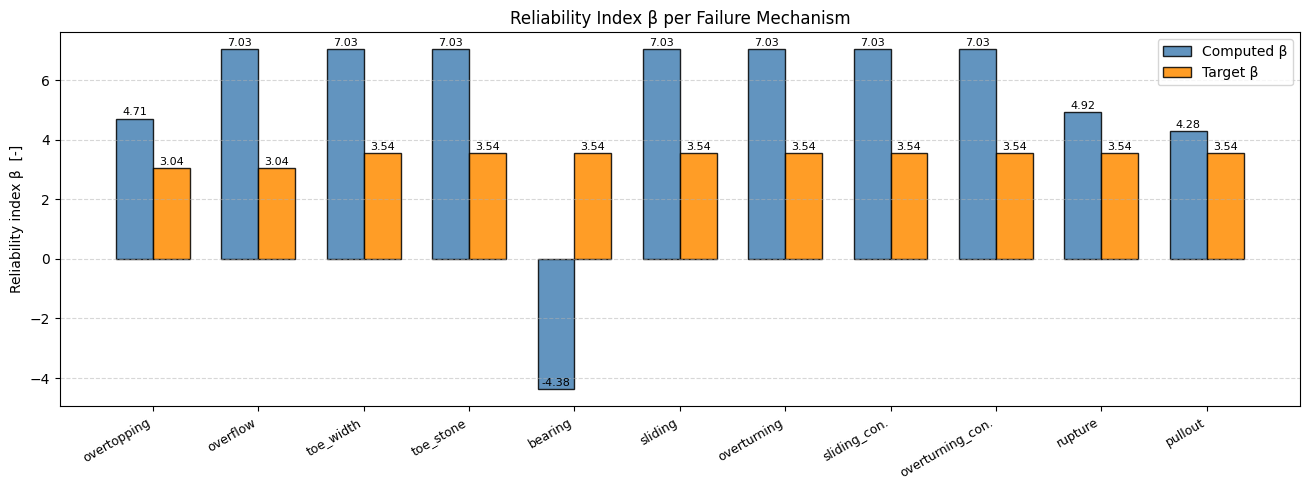

In [5]:
# --- Flags: toggle analyses ---
RUN_DETERMINISTIC = True
RUN_FORM          = True
RUN_MC_CROSSCHECK = True
MC_SIZE           = 200_000
MC_SEED           = 42
PLOT_RESULTS      = True  # FORM-unavailable mechanisms are clearer in the table.
SAVE_FIGURE       = False

# 1. Deterministic unity checks
if RUN_DETERMINISTIC:
    run_deterministic_checks()

# 2 + 3. FORM (+ optional MCS)
if RUN_FORM:
    results = run_form_all(
        mc_crosscheck = RUN_MC_CROSSCHECK,
        mc_size       = MC_SIZE,
        mc_seed       = MC_SEED,
    )
    compare_to_targets(results)
    if RUN_MC_CROSSCHECK:
        compare_form_to_mcs(results)

    if PLOT_RESULTS:
        plot_data = {k: v for k, v in results.items()
                     if "all_layers" not in str(k)}
        save_path = "results/beta_overview.png" if SAVE_FIGURE else None
        os.makedirs("results", exist_ok=True)
        plot_beta_overview(plot_data, save_path=save_path)

### External stability check

In [6]:
# Quick diagnostic bearing — run this before FORM
from Lsf_external import _vertical_load, _horizontal_load
uc = unity_checks_external(phi_deg=32.5, su_kPa=12.0, hgwl_val=0.10)
print(uc)

# Also check what Vd and R_bearing are at mean values
hgwl_mean = 0.10
Vd = _vertical_load(hgwl_mean, P.q_det)
phi_deg = 32.5
F_H = _horizontal_load(phi_deg, hgwl_mean)[0]
su_mean = 12.0
A = P.B
ratio = min(F_H / (A * su_mean), 1.0)
eta_H = 0.5 * (1 + np.sqrt(max(1 - ratio, 0)))
R_bearing = A * P.N_c * su_mean * eta_H
print(f"Vd = {Vd:.1f} kN/m")
print(f"R_bearing = {R_bearing:.1f} kN/m")
print(f"UC = {Vd/R_bearing:.2f}")

{'operational case': {'V_unfav [kN/m]': 2104.95, 'V_fav [kN/m]': 1337.0, 'F_H [kN/m]': 179.4, 'z_arm [m]': 2.532, 'bearing': {'UC': 9.986, 'passes': False}, 'sliding': {'UC': 0.329, 'passes': True}, 'rotation': {'UC': 0.204, 'passes': True}}, 'construction case': {'V_unfav [kN/m]': 2104.95, 'V_fav [kN/m]': 1337.0, 'F_H [kN/m]': 212.55, 'z_arm [m]': 2.272, 'bearing': {'UC': 'N/A', 'passes': True}, 'sliding': {'UC': 0.39, 'passes': True}, 'rotation': {'UC': 0.217, 'passes': True}}}
Vd = 2105.0 kN/m
R_bearing = 308.4 kN/m
UC = 6.83


### Internal stability check 

In [7]:
# Governing internal-layer comparison from the retained FORM and MCS results
if RUN_MC_CROSSCHECK:
    for mechanism in ["rupture", "pullout"]:
        result = results[mechanism]
        print(f"\n--- Governing {mechanism} layer: z = {result['governing_z']:.2f} m ---")
        print(f"  Pf FORM      = {result['pf']:.3e}")
        print(f"  MCS failures = {result['mc_failures']}/{result['mc_size']}")
        print(f"  Pf MCS       = {result['pf_mc']:.3e}")
        print(f"  MCS upper 95%= {result['pf_mc_upper_95']:.3e}")
        print(f"  Pf target    = {result['target']:.3e}")


--- Governing rupture layer: z = 7.50 m ---
  Pf FORM      = 4.266e-07
  MCS failures = 1/200000
  Pf MCS       = 5.000e-06
  MCS upper 95%= 2.372e-05
  Pf target    = 2.000e-04

--- Governing pullout layer: z = 0.50 m ---
  Pf FORM      = 9.439e-06
  MCS failures = 1/200000
  Pf MCS       = 5.000e-06
  MCS upper 95%= 2.372e-05
  Pf target    = 2.000e-04


In [8]:
# Find minimum B that satisfies pull-out at the governing layer
from scipy.stats import norm
from Lsf_internal import _Ka, _sigma_v


target_beta = -norm.ppf(P.pf_target("pullout"))
print(f"Required β for pull-out: {target_beta:.3f}")
print(f"\nSensitivity of UC_pullout at bottom layer to B:")
print(f"{'B [m]':>8} {'B/H':>6} {'Le [m]':>8} {'UC_po':>8}")

phi_deg   = 32.5
phi_rad   = np.radians(phi_deg)
tan_phi_d = np.tan(phi_rad) / 1.25
phi_d     = np.degrees(np.arctan(tan_phi_d))
z_i       = P.H  # bottom layer

for B_test in np.arange(P.H, 1.8 * P.H, 0.5):
    wedge  = z_i * np.tan(np.radians(45) - phi_rad/2)
    Le     = max(B_test - wedge, 0.0)
    sigma_v = _sigma_v(z_i, hgwl=0.10, q_surcharge=P.q_det)
    Ka_d   = _Ka(phi_d)
    T_d    = 1.35 * Ka_d * sigma_v * P.S_v
    mu_star = min(0.80 * tan_phi_d, 1.0)
    R_po   = mu_star * P.f_dg * 2.0 * sigma_v * Le / 1.20
    UC     = T_d / R_po if R_po > 0 else np.inf
    print(f"{B_test:>8.2f} {B_test/P.H:>6.2f} {Le:>8.3f} {UC:>8.3f}")

Required β for pull-out: 3.540

Sensitivity of UC_pullout at bottom layer to B:
   B [m]    B/H   Le [m]    UC_po
    7.50   1.00    3.385    1.542
    8.00   1.07    3.885    1.344
    8.50   1.13    4.385    1.191
    9.00   1.20    4.885    1.069
    9.50   1.27    5.385    0.969
   10.00   1.33    5.885    0.887
   10.50   1.40    6.385    0.818
   11.00   1.47    6.885    0.758
   11.50   1.53    7.385    0.707
   12.00   1.60    7.885    0.662
   12.50   1.67    8.385    0.623
   13.00   1.73    8.885    0.588


## Partial safety factor derivation

In [11]:
# ===========================================================================
# FORM-derived partial safety factor intermediate table
# ===========================================================================
# Run this cell after the main FORM analysis cell above. The table shows the
# intermediate quantities used when the PSFs are derived from converged FORM
# design points instead of from the JCSS fixed-alpha fallback.
# Here x_d_FORM is the physical-space FORM design point.
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import norm

if "results" not in globals():
    raise RuntimeError("Run the main FORM analysis cell first; it creates `results`.")


def _scalar(value):
    return float(np.asarray(value, dtype=float).reshape(-1)[0])


def _quantile_1d(distribution, probability):
    return _scalar(distribution.computeQuantile(probability))


def _cdf_1d(distribution, value):
    try:
        return float(distribution.computeCDF(float(value)))
    except TypeError:
        return float(distribution.computeCDF([float(value)]))


def _distribution_name(distribution):
    for getter in ("getName", "getClassName"):
        try:
            name = getattr(distribution, getter)()
        except Exception:
            continue
        if name:
            return str(name)
    return type(distribution).__name__


def _distribution_stats(distribution):
    mean = _scalar(distribution.getMean())
    std = _scalar(distribution.getStandardDeviation())
    cov = std / abs(mean) if abs(mean) > 1e-12 else np.nan
    return mean, std, cov


def _gamma_from_form_design_point(role, x_k, x_star):
    if role == "inert":
        return 1.0
    if not (np.isfinite(x_k) and np.isfinite(x_star)):
        return np.nan
    if role == "resistance":
        return x_k / x_star if abs(x_star) > 1e-12 else np.inf
    return x_star / x_k if abs(x_k) > 1e-12 else np.inf


# Rebuild the same hydraulic distribution used by the overtopping FORM run so
# the hydraulic mean, standard deviation, CoV and marginal CDF values can be
# shown next to the retained FORM design point.
hydraulic_margins_for_psf = fit_hydra_margins()
hydraulic_distribution_for_psf = build_openturns_hydraulic_distribution(
    spearman_rho=SPEARMAN_RHO_SWL_HM0,
    margins=hydraulic_margins_for_psf,
)

form_psf_specs = {
    "overtopping": {
        "variables": [
            {
                "name": "SWL",
                "distribution": hydraulic_distribution_for_psf.getMarginal(0),
                "role": "load",
                "x_k": P.h_d833,
                "x_k_source": "T=833 design value",
                "note": "joint hydraulic FORM",
            },
            {
                "name": "Hm0",
                "distribution": hydraulic_distribution_for_psf.getMarginal(1),
                "role": "load",
                "x_k": P.H_s833,
                "x_k_source": "T=833 design value",
                "note": "Tm derived from Hm0 quantile",
            },
        ],
        "spearman_rho": SPEARMAN_RHO_SWL_HM0,
        #SWL and Hm0 coupled with Gaussian copula , rescale is not consistent with Nataf transform
        "rescale_to_target": False,
    },
    "rupture": {
        "variables": [
            {
                "name": "tan_phi",
                "distribution": P.tan_phi,
                "role": "resistance",
                "x_k": _quantile_1d(P.tan_phi, 0.05),
                "x_k_source": "lower 5% fractile",
                "note": "backfill friction",
            },
            {
                "name": "Rt",
                "distribution": P.Rt,
                "role": "resistance",
                "x_k": _quantile_1d(P.Rt, 0.05),
                "x_k_source": "lower 5% fractile",
                "note": "tensile resistance",
            },
            {
                "name": "hgwl",
                "distribution": P.hgwl,
                "role": "load",
                "x_k": 0.10,
                "x_k_source": "design value",
                "note": "groundwater level; read gamma as design-value ratio",
            },
            {
                "name": "q_surcharge",
                "distribution": P.q_sur,
                "role": "load",
                "x_k": _quantile_1d(P.q_sur, 0.95),
                "x_k_source": "upper 95% fractile",
                "note": "traffic surcharge",
            },
        ],
    },
    "pullout": {
        "variables": [
            {
                "name": "tan_phi",
                "distribution": P.tan_phi,
                "role": "resistance",
                "x_k": _quantile_1d(P.tan_phi, 0.05),
                "x_k_source": "lower 5% fractile",
                "note": "backfill friction",
            },
            {
                "name": "fb",
                "distribution": P.fb,
                "role": "resistance",
                "x_k": _quantile_1d(P.fb, 0.05),
                "x_k_source": "lower 5% fractile",
                "note": "bond factor",
            },
            {
                "name": "hgwl",
                "distribution": P.hgwl,
                "role": "load",
                "x_k": 0.10,
                "x_k_source": "design value",
                "note": "groundwater level; read gamma as design-value ratio",
            },
            {
                "name": "q_surcharge",
                "distribution": P.q_sur,
                "role": "inert",
                "x_k": _quantile_1d(P.q_sur, 0.95),
                "x_k_source": "upper 95% fractile",
                "note": "inert in pull-out ratio",
            },
        ],
    },
}

rows = []
for mechanism, spec in form_psf_specs.items():
    form_result = results.get(mechanism, {})
    if form_result.get("form_status") != "OK":
        continue

    x_star_values = np.asarray(form_result.get("x_star", []), dtype=float)
    u_star_values = np.asarray(form_result.get("u_star", []), dtype=float)
    beta_form = float(form_result.get("beta", np.nan))
    pf_form = float(form_result.get("pf", np.nan))
    pf_target = float(form_result.get("target", np.nan))
    beta_target = float(-norm.ppf(pf_target)) if np.isfinite(pf_target) else np.nan



    rescale_to_target = bool(spec.get("rescale_to_target",True))
    can_rescale = (rescale_to_target
                   and np.isfinite(beta_form) and beta_form > 0
                   and np.isfinite(beta_target))
    scale = beta_target / beta_form if can_rescale else 1.0

    for index, variable in enumerate(spec["variables"]):
        distribution = variable["distribution"]
        x_star = x_star_values[index] if index < len(x_star_values) else np.nan
        u_star = u_star_values[index] if index < len(u_star_values) else np.nan
        x_k = float(variable["x_k"])
        mean, std, cov = _distribution_stats(distribution)

        u_d = u_star * scale if np.isfinite(u_star) else np.nan
        if can_rescale and np.isfinite(u_star):
            p_d = float(np.clip(norm.cdf(u_d), 1e-15, 1.0 - 1e-15))
            x_d = _quantile_1d(distribution, p_d)
        else:
            x_d = x_star

        alpha_form = (-u_star / beta_form
                      if np.isfinite(u_star) and np.isfinite(beta_form) and beta_form > 0
                      else np.nan)
        alpha2_importance = alpha_form**2 if np.isfinite(alpha_form) else np.nan
        gamma_raw = _gamma_from_form_design_point(variable["role"], x_k, x_d)
        gamma_adopted = max(1.0, gamma_raw) if np.isfinite(gamma_raw) else gamma_raw

        rows.append({
            "mechanism": mechanism,
            "variable": variable["name"],
            "role": variable["role"],
            "governing_z_m": form_result.get("governing_z", np.nan),
            "spearman_rho": spec.get("spearman_rho", np.nan),
            "pf_FORM": pf_form,
            "pf_target": pf_target,
            "beta_FORM": beta_form,
            "beta_target": beta_target,
            "distribution": _distribution_name(distribution),
            "mean": mean,
            "std": std,
            "CoV": cov,
            "x_k": x_k,
            "x_k_source": variable["x_k_source"],
            "beta_scale": scale,
            "x_star_FORM": x_star,
            "u_star_FORM": u_star,
            "x_d_target": x_d,
            "u_d_target": u_d,
            "F_X(x_d)": (_cdf_1d(distribution, x_d)
                         if np.isfinite(x_d) else np.nan),
            "alpha_FORM": alpha_form,
            "alpha2_importance": alpha2_importance,
            "gamma_raw_FORM": gamma_raw,
            "gamma_adopted": gamma_adopted,
            "note": variable["note"],
        })

form_psf_intermediate_table = pd.DataFrame(rows)

formatters = {
    "governing_z_m": "{:.2f}",
    "spearman_rho": "{:.2f}",
    "pf_FORM": "{:.3e}",
    "pf_target": "{:.3e}",
    "beta_FORM": "{:.3f}",
    "beta_target": "{:.3f}",
    "mean": "{:.4g}",
    "std": "{:.4g}",
    "CoV": "{:.3f}",
    "x_k": "{:.4g}",
    "beta_scale": "{:.3f}",
    "x_star_FORM": "{:.4g}",
    "u_star_FORM": "{:.4g}",
    "x_d_target": "{:.4g}",
    "u_d_target": "{:.4g}",
    "F_X(x_d)": "{:.3f}",
    "alpha_FORM": "{:+.3f}",
    "alpha2_importance": "{:.3f}",
    "gamma_raw_FORM": "{:.3f}",
    "gamma_adopted": "{:.3f}",
}

print("FORM-derived PSF table: alpha_FORM = -u_star / beta_FORM; alpha2_importance = alpha_FORM**2.")
print("For unfavourable/load variables gamma = x_d / x_k; for favourable/resistance variables gamma = x_k / x_d.")
display(
    form_psf_intermediate_table.style
    .format(formatters, na_rep="-")
    .set_caption("FORM-derived partial safety factor intermediate parameters")
)


FORM-derived PSF table: alpha_FORM = -u_star / beta_FORM; alpha2_importance = alpha_FORM**2.
For unfavourable/load variables gamma = x_d / x_k; for favourable/resistance variables gamma = x_k / x_d.


,mechanism,variable,role,governing_z_m,spearman_rho,pf_FORM,pf_target,beta_FORM,beta_target,distribution,mean,std,CoV,x_k,x_k_source,beta_scale,x_star_FORM,u_star_FORM,x_d_target,u_d_target,F_X(x_d),alpha_FORM,alpha2_importance,gamma_raw_FORM,gamma_adopted,note
0,overtopping,SWL,load,-,0.37,1.241e-06,1.200e-03,4.710,3.036,Gumbel,1.176,0.1499,0.127,1.86,T=833 design value,1.000,2.064,3.448,2.064,3.448,1.000,-0.732,0.536,1.110,1.110,joint hydraulic FORM
1,overtopping,Hm0,load,-,0.37,1.241e-06,1.200e-03,4.710,3.036,Gumbel,0.8324,0.1003,0.120,1.32,T=833 design value,1.000,1.693,3.208,1.693,3.208,1.000,-0.681,0.464,1.282,1.282,Tm derived from Hm0 quantile
2,rupture,tan_phi,resistance,7.50,-,4.266e-07,2.000e-04,4.923,3.540,tan_phi,0.6371,0.06371,0.100,0.538,lower 5% fractile,0.719,0.4941,-2.498,0.5299,-1.797,0.036,+0.507,0.258,1.015,1.015,backfill friction
3,rupture,Rt,resistance,7.50,-,4.266e-07,2.000e-04,4.923,3.540,R_t,42.29,6.343,0.150,32.72,lower 5% fractile,0.719,22.29,-4.217,26.6,-3.033,0.001,+0.857,0.734,1.230,1.230,tensile resistance
4,rupture,hgwl,load,7.50,-,4.266e-07,2.000e-04,4.923,3.540,h_gwl,0.1667,0.165,0.990,0.1,design value,0.719,0.1037,-0.2943,0.1168,-0.2116,0.416,+0.060,0.004,1.168,1.168,groundwater level; read gamma as design-value ratio
5,rupture,q_surcharge,load,7.50,-,4.266e-07,2.000e-04,4.923,3.540,q_surcharge,11.67,1.434,0.123,13.98,upper 95% fractile,0.719,12.24,0.3492,12.1,0.2511,0.599,-0.071,0.005,0.866,1.000,traffic surcharge
6,pullout,tan_phi,resistance,0.50,-,9.439e-06,2.000e-04,4.278,3.540,tan_phi,0.6371,0.06371,0.100,0.538,lower 5% fractile,0.828,0.4291,-3.912,0.459,-3.237,0.001,+0.914,0.836,1.172,1.172,backfill friction
7,pullout,fb,resistance,0.50,-,9.439e-06,2.000e-04,4.278,3.540,f_b,0.8,0.08165,0.102,0.6632,lower 5% fractile,0.828,0.6577,-1.731,0.6779,-1.433,0.076,+0.405,0.164,0.978,1.000,bond factor
8,pullout,hgwl,load,0.50,-,9.439e-06,2.000e-04,4.278,3.540,h_gwl,0.1667,0.165,0.990,0.1,design value,0.828,0.1528,0,0.1528,0,0.500,-0.000,0.000,1.528,1.528,groundwater level; read gamma as design-value ratio
9,pullout,q_surcharge,inert,0.50,-,9.439e-06,2.000e-04,4.278,3.540,q_surcharge,11.67,1.434,0.123,13.98,upper 95% fractile,0.828,11.74,-4.254e-08,11.74,-3.521e-08,0.500,+0.000,0.000,1.000,1.000,inert in pull-out ratio


In [ ]:
import Output as O
import Parameters as P

psf_dict = O.compute_psf_table(P)
O.print_psf_table(psf_dict)


  PARTIAL SAFETY FACTORS  –  JCSS fixed-α method  (fallback, FORM unavailable)
  Characteristic values: lower 5% (resistance-role) / upper 95% (load-role) fractile
  Mechanism        Variable      α    β_t      x_k        x*   γ_raw  γ_adopt   γ_code   ratio
  --------------------------------------------------------------------------------------
  toe_stone        phi_stone +0.80  3.540     35.1   31.6680   1.108    1.108        —       —
  --------------------------------------------------------------------------------------
  bearing          su        +0.80  3.540     7.76    5.7967   1.340    1.340     1.40    0.96
                   tan_phi     —    3.540    0.538    0.5380   1.000    1.000     1.25    0.80
                   hgwl      -0.28  3.540      0.1    0.3464   3.464    3.464        —       —
                   q_sur     -0.70  3.540       14   14.6276   1.047    1.047     1.50    0.70
  -------------------------------------------------------------------------------------